In [53]:
import mlflow
import os
import pandas as pd


In [54]:
MLFLOW_SERVER_IP = "192.168.1.103"
MLFLOW_SERVER_IP = "localhost"
# MLflow
os.environ["MLFLOW_TRACKING_URI"] = f"http://{MLFLOW_SERVER_IP}:5000"

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
# MinIO
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = f"http://{MLFLOW_SERVER_IP}:9000"

def get_exp_trials(experiment_name, return_artifacts = True, timeout=10):
    """
    Get all trials (runs) from a specific MLFlow experiment.
    
    Args:
        experiment_name (str): Name of the MLflow experiment
        timeout (int): Timeout in seconds for operations (default: 10)
        
    Returns:
        pd.DataFrame: DataFrame containing all runs with their metrics, parameters, and metadata
        None: If experiment not found or connection fails
    """
    tracking_uri = os.environ.get("MLFLOW_TRACKING_URI")
    print(f"Testing connection to MLflow server: {tracking_uri}")
    
    # Test if server is reachable
    try:
        response = requests.get(tracking_uri, timeout=5)
        print(f"✓ MLflow server is reachable (status: {response.status_code})")
    except requests.exceptions.Timeout:
        print("✗ Connection timed out. Server might be down or unreachable.")
        return None
    except requests.exceptions.ConnectionError:
        print("✗ Connection error. Check if server is running and network is available.")
        return None
    except Exception as e:
        print(f"✗ Error connecting to server: {e}")
        return None
    
    # Set timeout for MLflow operations
    os.environ["MLFLOW_HTTP_REQUEST_TIMEOUT"] = str(timeout)
    
    print(f"Creating MLflow client...")
    client = mlflow.tracking.MlflowClient()
    
    print(f"Getting experiment: '{experiment_name}'...")
    try:
        # Get the experiment by name
        experiment = client.get_experiment_by_name(experiment_name)
        print(f"✓ Found experiment: {experiment.name if experiment else None}")
    except Exception as e:
        print(f"✗ Error getting experiment: {e}")
        return None
    
    if not experiment:
        print(f"✗ MLflow experiment '{experiment_name}' not found.")
        return None
    
    # Search all runs in the experiment
    print(f"Searching for runs in experiment...")
    try:
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            order_by=["start_time DESC"]  # Most recent first
        )
        print(f"✓ Found {len(runs)} runs")
    except Exception as e:
        print(f"✗ Error searching runs: {e}")
        return None
    
    if not runs:
        print(f"⚠ No runs found in experiment '{experiment_name}'")
        return pd.DataFrame()

    # Convert runs to dicts
    print(f"Converting {len(runs)} runs to DataFrame...")
    runs_data = []
    artifacts = {}
    for run in runs:
        run_dict = {
            'run_id': run.info.run_id,
            'run_name': run.info.run_name,
            'status': run.info.status,
            'start_time': pd.to_datetime(run.info.start_time, unit='ms'),
            'end_time': pd.to_datetime(run.info.end_time, unit='ms') if run.info.end_time else None,
        }
        
        # Add all metrics, params, and tags
        run_dict.update({f'metric_{k}': v for k, v in run.data.metrics.items()})
        #run_dict.update({f'param_{k}': v for k, v in run.data.params.items()})
        #run_dict.update({f'tag_{k}': v for k, v in run.data.tags.items()})

        print(run.info.artifact_uri)

        if return_artifacts:
            artifacts[run_dict['run_name']] = None
        
        runs_data.append(run_dict)
    
    df = pd.DataFrame(runs_data)
    print(f"✓ Successfully created DataFrame with {len(df)} rows and {len(df.columns)} columns")

    if return_artifacts:
        return df, artifacts
    return df


In [55]:
# Get all trials from an experiment

exp_name = 'daily_search2'
time = "Daily"

# Call with timeout parameter (default is 10 seconds, increase if needed)
trials_df, artifacts = get_exp_trials(exp_name, timeout=15)

# Display the results
if trials_df is not None and not trials_df.empty:
    print(f"\n📊 Retrieved {len(trials_df)} trials")
    display(trials_df.head())

Testing connection to MLflow server: http://localhost:5000
✓ MLflow server is reachable (status: 200)
Creating MLflow client...
Getting experiment: 'daily_search2'...
✓ Found experiment: daily_search2
Searching for runs in experiment...
✓ Found 20 runs
Converting 20 runs to DataFrame...
s3://mlflow/25/805ed1b83961412886a413309bc2d123/artifacts
s3://mlflow/25/032b3873a62d4213af62a633e91cef24/artifacts
s3://mlflow/25/ef4b907aa4584b579cf298d2018c06d4/artifacts
s3://mlflow/25/1fce32a9a8b041409dd886ee656e3abc/artifacts
s3://mlflow/25/d115196617a74a91868ffd3d6c1114df/artifacts
s3://mlflow/25/f2816a4023cd42658151c74e174b2517/artifacts
s3://mlflow/25/8bc55936777e488a997e4126763f80db/artifacts
s3://mlflow/25/4bc68ddcbdab40f5be929e5a66b642a9/artifacts
s3://mlflow/25/d50dd07325cd4d71a2aeee1ee0973764/artifacts
s3://mlflow/25/af874e861c3e404291917b6490b92819/artifacts
s3://mlflow/25/e228880a69944c7782ea3606da7d5bc6/artifacts
s3://mlflow/25/fe12dee0e92d46a2bb9dce9bf8857f42/artifacts
s3://mlflow/25/7

,run_id,run_name,status,start_time,end_time,metric_train_mse_loss,metric_vali_mse_loss,metric_vali_mda_metric,metric_test_mse_loss,metric_test_mda_metric,...,metric_RMSE_5,metric_RMSE_6,metric_RMSE_7,metric_RMSE_8,metric_RMSE_9,metric_RMSE_10,metric_RMSE_11,metric_RMSE_12,metric_RMSE_13,metric_RMSE_14
0,805ed1b83961412886a413309bc2d123,trial_a8ec6659_daily_full_dates_2016-01-01_202...,RUNNING,2025-12-04 22:05:34.177,NaT,0.023784,0.001693,0.512019,0.001371,0.495192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,032b3873a62d4213af62a633e91cef24,trial_182bc07b_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 22:01:27.262,2025-12-04 22:05:15.943,49139.057031,37178.776289,0.497115,25955.961668,0.495673,...,0.032511,0.054100,0.044660,0.051463,0.047165,0.050734,0.050460,0.031069,0.038461,0.030502
2,ef4b907aa4584b579cf298d2018c06d4,trial_0b010a94_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 21:55:00.889,2025-12-04 22:01:08.638,4571.982068,12847.611481,0.503365,16685.953363,0.507212,...,0.030937,0.030416,0.030548,0.030852,0.031357,0.030588,0.030348,0.030375,0.030822,0.030378
3,1fce32a9a8b041409dd886ee656e3abc,trial_ffd44a69_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 21:49:20.189,2025-12-04 21:54:41.885,0.001310,0.000777,0.501202,0.000978,0.496394,...,0.031745,0.030300,0.030933,0.032524,0.030414,0.030808,0.030297,0.030173,0.031446,0.030075
4,d115196617a74a91868ffd3d6c1114df,trial_66247251_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 21:43:53.806,2025-12-04 21:49:01.423,8495.730957,13904.115332,0.497596,18918.856467,0.498558,...,0.031794,0.031425,0.039053,0.033430,0.047222,0.040225,0.037198,0.033659,0.030755,0.031533


In [56]:
df = trials_df.copy()
df.head()

,run_id,run_name,status,start_time,end_time,metric_train_mse_loss,metric_vali_mse_loss,metric_vali_mda_metric,metric_test_mse_loss,metric_test_mda_metric,...,metric_RMSE_5,metric_RMSE_6,metric_RMSE_7,metric_RMSE_8,metric_RMSE_9,metric_RMSE_10,metric_RMSE_11,metric_RMSE_12,metric_RMSE_13,metric_RMSE_14
0,805ed1b83961412886a413309bc2d123,trial_a8ec6659_daily_full_dates_2016-01-01_202...,RUNNING,2025-12-04 22:05:34.177,NaT,0.023784,0.001693,0.512019,0.001371,0.495192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,032b3873a62d4213af62a633e91cef24,trial_182bc07b_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 22:01:27.262,2025-12-04 22:05:15.943,49139.057031,37178.776289,0.497115,25955.961668,0.495673,...,0.032511,0.054100,0.044660,0.051463,0.047165,0.050734,0.050460,0.031069,0.038461,0.030502
2,ef4b907aa4584b579cf298d2018c06d4,trial_0b010a94_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 21:55:00.889,2025-12-04 22:01:08.638,4571.982068,12847.611481,0.503365,16685.953363,0.507212,...,0.030937,0.030416,0.030548,0.030852,0.031357,0.030588,0.030348,0.030375,0.030822,0.030378
3,1fce32a9a8b041409dd886ee656e3abc,trial_ffd44a69_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 21:49:20.189,2025-12-04 21:54:41.885,0.001310,0.000777,0.501202,0.000978,0.496394,...,0.031745,0.030300,0.030933,0.032524,0.030414,0.030808,0.030297,0.030173,0.031446,0.030075
4,d115196617a74a91868ffd3d6c1114df,trial_66247251_daily_full_dates_2016-01-01_202...,FINISHED,2025-12-04 21:43:53.806,2025-12-04 21:49:01.423,8495.730957,13904.115332,0.497596,18918.856467,0.498558,...,0.031794,0.031425,0.039053,0.033430,0.047222,0.040225,0.037198,0.033659,0.030755,0.031533


In [57]:
df.drop(columns=['run_id', 'status', 'start_time', 'end_time'], inplace=True)
df['start'] = df['run_name'].str.split('_').str[5]
df['end'] = df['run_name'].str.split('_').str[6]
df['start'] = pd.to_datetime(df['start'], format='%Y-%m-%d %H:%M:%S')
df['end'] = pd.to_datetime(df['end'], format='%Y-%m-%d %H:%M:%S')
df.head()


,run_name,metric_train_mse_loss,metric_vali_mse_loss,metric_vali_mda_metric,metric_test_mse_loss,metric_test_mda_metric,metric_inf_pred_1_mda,metric_inf_pred_2_mda,metric_inf_pred_3_mda,metric_inf_pred_4_mda,...,metric_RMSE_7,metric_RMSE_8,metric_RMSE_9,metric_RMSE_10,metric_RMSE_11,metric_RMSE_12,metric_RMSE_13,metric_RMSE_14,start,end
0,trial_a8ec6659_daily_full_dates_2016-01-01_202...,0.023784,0.001693,0.512019,0.001371,0.495192,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01,2020-12-31
1,trial_182bc07b_daily_full_dates_2016-01-01_202...,49139.057031,37178.776289,0.497115,25955.961668,0.495673,0.470911,0.498901,0.49835,0.495595,...,0.044660,0.051463,0.047165,0.050734,0.050460,0.031069,0.038461,0.030502,2016-01-01,2020-12-31
2,trial_0b010a94_daily_full_dates_2016-01-01_202...,4571.982068,12847.611481,0.503365,16685.953363,0.507212,0.475302,0.501099,0.49615,0.495595,...,0.030548,0.030852,0.031357,0.030588,0.030348,0.030375,0.030822,0.030378,2016-01-01,2020-12-31
3,trial_ffd44a69_daily_full_dates_2016-01-01_202...,0.001310,0.000777,0.501202,0.000978,0.496394,0.476400,0.498901,0.49615,0.494493,...,0.030933,0.032524,0.030414,0.030808,0.030297,0.030173,0.031446,0.030075,2016-01-01,2020-12-31
4,trial_66247251_daily_full_dates_2016-01-01_202...,8495.730957,13904.115332,0.497596,18918.856467,0.498558,0.475302,0.502198,0.49505,0.493392,...,0.039053,0.033430,0.047222,0.040225,0.037198,0.033659,0.030755,0.031533,2016-01-01,2020-12-31


In [58]:
for col in df.columns:
    if col.split("_")[0] == "param":
        df.drop(columns=[col], inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[-1] == "mda":
        pred = col.split("_")[-2]
        df.rename(columns={col: f"mda_{pred}"}, inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[-1] == "mse":
        pred = col.split("_")[-2]
        df.rename(columns={col: f"mse_{pred}"}, inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[1].lower() == "rmse":
        pred = col.split("_")[-1]
        df.rename(columns={col: f"rmse_{pred}"}, inplace=True)
    elif col.split("_")[0] == "tag":
        df.drop(columns=[col], inplace=True)
    elif col.split("_")[0] == "metric":
        name = "_".join(col.split("_")[1:])
        df.rename(columns={col: name}, inplace=True)



df.head()

print(df.columns)
df.sort_values(by="start", ascending=True, inplace=True)

Index(['run_name', 'train_mse_loss', 'vali_mse_loss', 'vali_mda_metric',
       'test_mse_loss', 'test_mda_metric', 'mda_1', 'mda_2', 'mda_3', 'mda_4',
       'mda_5', 'mda_6', 'mda_7', 'mda_8', 'mda_9', 'mda_10', 'mda_11',
       'mda_12', 'mda_13', 'mda_14', 'mse_1', 'mse_2', 'mse_3', 'mse_4',
       'mse_5', 'mse_6', 'mse_7', 'mse_8', 'mse_9', 'mse_10', 'mse_11',
       'mse_12', 'mse_13', 'mse_14', 'rmse_1', 'rmse_2', 'rmse_3', 'rmse_4',
       'rmse_5', 'rmse_6', 'rmse_7', 'rmse_8', 'rmse_9', 'rmse_10', 'rmse_11',
       'rmse_12', 'rmse_13', 'rmse_14', 'start', 'end'],
      dtype='object')


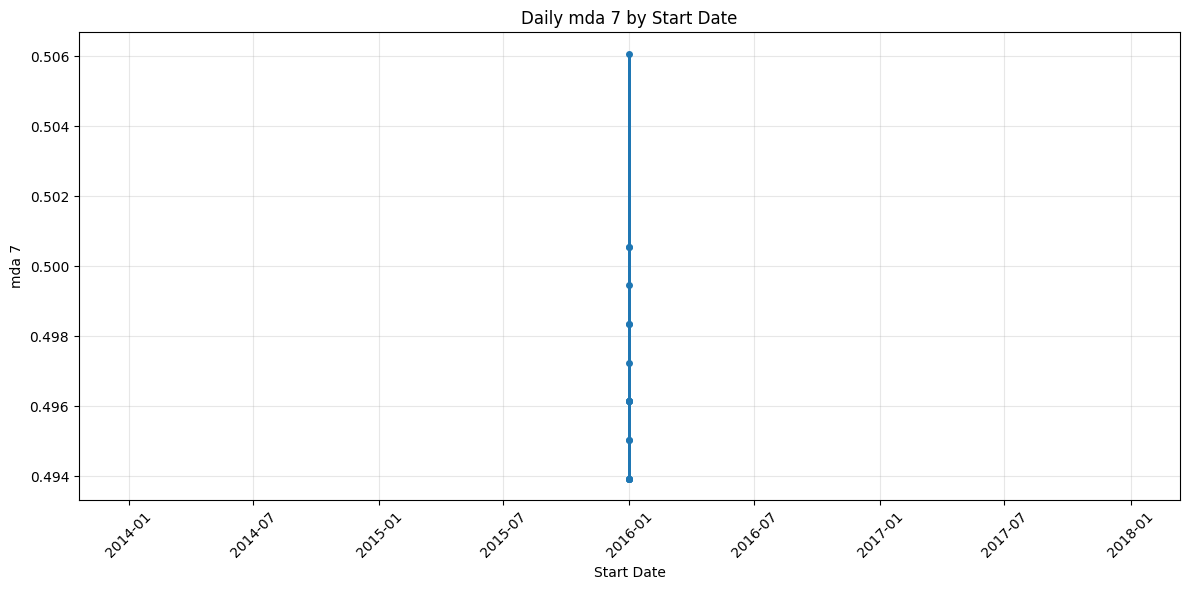

In [59]:
import matplotlib.pyplot as plt

pred = 7
metric = "mda"


plt.figure(figsize=(12, 6))
plt.plot(df['start'], df[f'{metric}_{pred}'], marker='o', linewidth=2, markersize=4)
plt.xlabel('Start Date')
plt.ylabel(f'{metric} {pred}')
plt.title(f'{time} {metric} {pred} by Start Date')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'plots/{time}_mdas.png')

plt.show()


In [60]:
aggregated_metrics = df.drop(columns=['start', 'end','run_name']).mean()

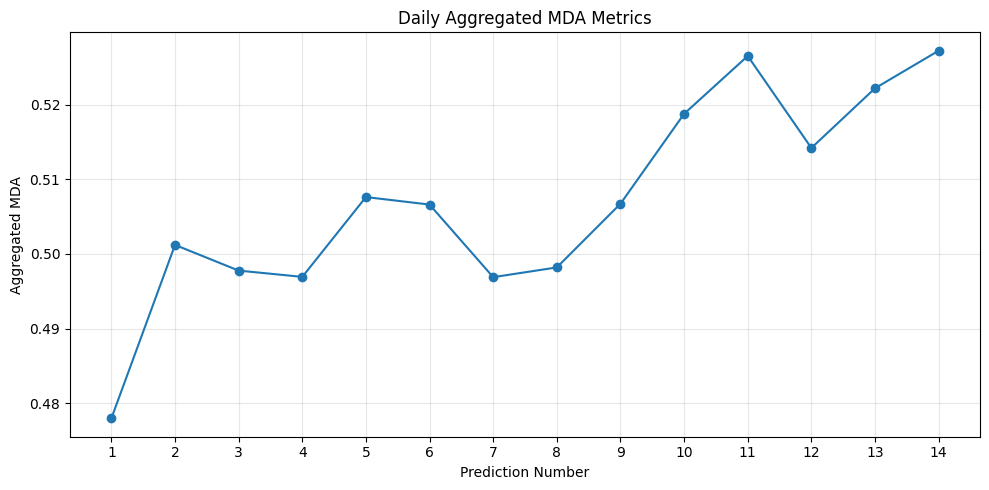

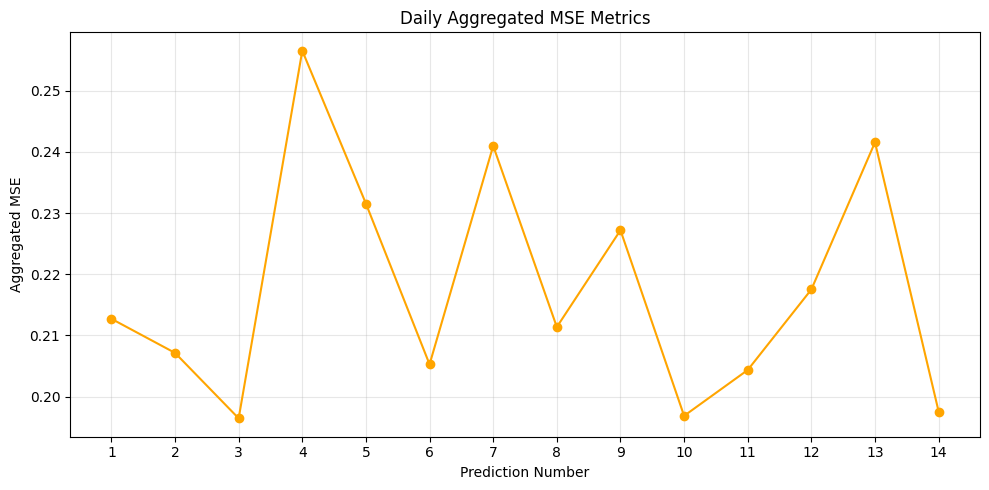

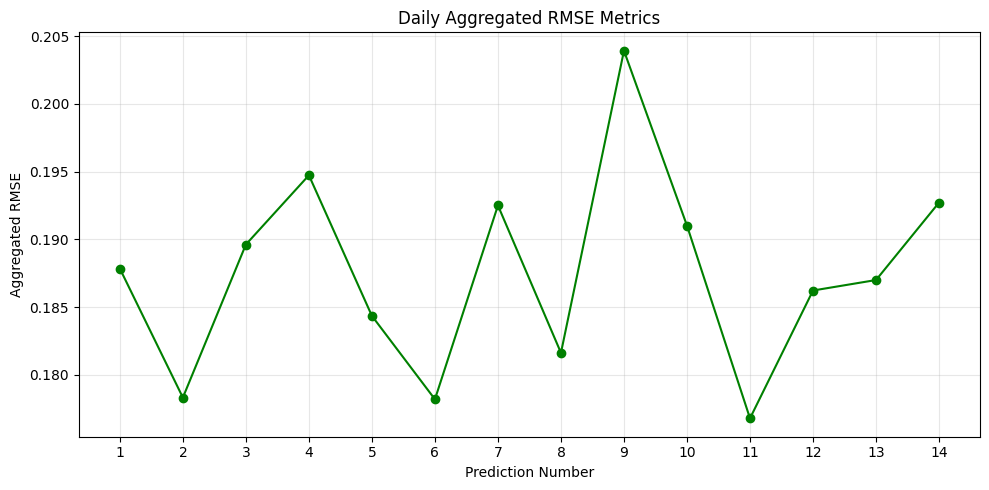

In [61]:
import re

# Get all metric names for mda, mse, and rmse
mda_cols = [col for col in aggregated_metrics.index if re.match(r"mda_\d+", col)]
mse_cols = [col for col in aggregated_metrics.index if re.match(r"mse_\d+", col)]
rmse_cols = [col for col in aggregated_metrics.index if re.match(r"rmse_\d+", col)]

# Extract numbers for sorting
def sort_key(col):
    return int(col.split('_')[1])

mda_cols_sorted = sorted(mda_cols, key=sort_key)
mse_cols_sorted = sorted(mse_cols, key=sort_key)
rmse_cols_sorted = sorted(rmse_cols, key=sort_key)

# Plot mda
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in mda_cols_sorted],
    [aggregated_metrics[col] for col in mda_cols_sorted],
    marker='o', label='MDA'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated MDA')
plt.title(f'{time} Aggregated MDA Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in mda_cols_sorted])
plt.savefig(f'plots/{time}_mdas.png')
plt.tight_layout()
plt.show()

# Plot mse
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in mse_cols_sorted],
    [aggregated_metrics[col] for col in mse_cols_sorted],
    marker='o', color='orange', label='MSE'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated MSE')
plt.title(f'{time} Aggregated MSE Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in mse_cols_sorted])
plt.savefig(f'plots/{time}_mses.png')
plt.tight_layout()
plt.show()

# Plot rmse
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in rmse_cols_sorted],
    [aggregated_metrics[col] for col in rmse_cols_sorted],
    marker='o', color='green', label='RMSE'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated RMSE')
plt.title(f'{time} Aggregated RMSE Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in rmse_cols_sorted])
plt.tight_layout()

plt.show()
